# Synthetic Probe Test — Evaluation on Real and Synthetic Extraction Data

Load trained probes saved by `synthetic_probe_analysis.ipynb` and evaluate them
on real extraction data.  Produces publication-ready figures and summary tables
for every combination of (train dataset, test dataset).

**Prerequisites**: Run `synthetic_probe_analysis.ipynb` for each
(dataset, judge_model) combination before running this notebook.

---

**Four evaluation settings** (for `DATASETS = ['pond', 'nfix']`):
1. pond trained → pond tested (within-domain)
2. nfix trained → nfix tested (within-domain)
3. pond trained → nfix tested (cross-domain)
4. nfix trained → pond tested (cross-domain)

**Per-combination outputs**:
- Calibration curve: NTP baseline vs. EM-rescaled probe predictions for each judge model
- Summary table: recovery rate, hallucination rate, ECE at threshold = 0.5
- Threshold sweep: recovery rate vs. hallucination rate as threshold varies 0.5 → 0.95

**Label definition** (`LABEL_MODE = 'union'`): a real extraction is positive
if it matches a ground-truth row **or** the majority-vote frontier judge says valid.

In [3]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from analysis.loaders import (
    load_activations, load_combined_judgements,
    load_extraction, load_ground_truth, load_trained_probe,
    cached_match, load_synthetic_activations, load_synthetic_layer_outputs, 
    load_synthetic_responses,
)
from scholarlm.utils.calibration import reliability_diagram_data, rescale_probabilities_em
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

FIGURES_DIR = "../figures/synthetic_probe/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

In [4]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASETS = ['pond', 'nfix']
EXTRACTION_MODEL = 'gemma-3-27b'
JUDGE_MODELS = ['llama-3.1-8b', 'mistral-7b', 'qwen-2.5-7b']

# Extraction date per test dataset
EXTRACTION_DATES = {
    'pond': '2026_04_30',
    'nfix': '2026_04_30',
}

# Judge date for synthetic test activations: {dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_SYN = {
    'pond': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
}

# Judge date for real activations: {test_dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_REAL = {
    'pond': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_04',
        'mistral-7b': '2026_05_04',
        'qwen-2.5-7b': '2026_05_04',
    },
}

THRESHOLD_SWEEP = np.linspace(0.5, 0.95, 15)  # thresholds for operating-curve plot
EDGE_THRESHOLD  = 1 / 3  # minimum fuzzy weight to count as a match

# Visual style
JUDGE_COLORS = {
    'llama-3.1-8b': '#3984e0',
    'mistral-7b':   '#2eb07b',
    'qwen-2.5-7b':   '#d946a6',
}

## Load Trained Probes

In [5]:
# probe_cache[train_dataset][judge_model] = probe_data dict
probe_cache = {}
for ds in DATASETS:
    probe_cache[ds] = {}
    for jm in JUDGE_MODELS:
        probe_cache[ds][jm] = load_trained_probe(ds, jm)
        top = probe_cache[ds][jm]['top_k_heads']
        print(f'  {ds} / {jm}: top heads={top}  pi_tr={probe_cache[ds][jm]["train_prevalence"]:.3f}')

  pond / llama-3.1-8b: top heads=[(np.int64(30), np.int64(19)), (np.int64(31), np.int64(12)), (np.int64(31), np.int64(14)), (np.int64(18), np.int64(26)), (np.int64(26), np.int64(22))]  pi_tr=0.333
  pond / mistral-7b: top heads=[(np.int64(18), np.int64(26)), (np.int64(26), np.int64(16)), (np.int64(30), np.int64(18)), (np.int64(31), np.int64(17)), (np.int64(20), np.int64(30))]  pi_tr=0.333
  pond / qwen-2.5-7b: top heads=[(np.int64(25), np.int64(19)), (np.int64(27), np.int64(9)), (np.int64(27), np.int64(24)), (np.int64(27), np.int64(22)), (np.int64(27), np.int64(8))]  pi_tr=0.333
  nfix / llama-3.1-8b: top heads=[(np.int64(17), np.int64(19)), (np.int64(15), np.int64(10)), (np.int64(15), np.int64(20)), (np.int64(20), np.int64(13)), (np.int64(22), np.int64(15))]  pi_tr=0.333
  nfix / mistral-7b: top heads=[(np.int64(30), np.int64(19)), (np.int64(20), np.int64(9)), (np.int64(16), np.int64(14)), (np.int64(14), np.int64(0)), (np.int64(25), np.int64(24))]  pi_tr=0.333
  nfix / qwen-2.5-7b: to

## Analysis Helpers

In [6]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import brier_score_loss


def _probe_metrics(probs, y_true, threshold=0.5):
    """Compute metrics at a fixed threshold. Returns dict."""
    probs   = np.asarray(probs)
    y_true  = np.asarray(y_true, dtype=bool)
    preds   = probs > threshold
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc   = (tp + tn) / n
    prec  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec   = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = roc_auc_score(y_true, probs) if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan')
    ece   = reliability_diagram_data(probs, y_true)['ece']
    bs    = float(brier_score_loss(y_true, probs))
    p_pos = float(y_true.mean())
    bss   = 1.0 - bs / (p_pos * (1 - p_pos)) if p_pos not in (0.0, 1.0) else float('nan')
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auroc=auroc,
                ece=ece, bs=bs, bss=bss, n=n)


def compute_rates(probs, threshold, real_test_labels, test_edges, n_gt):
    """Recovery rate and hallucination rate at a given threshold.

    At threshold t:
      accepted      = probs > t (accepted extractions)
      recovery      = fraction of GT rows matched by at least one accepted extraction
      hallucination = fraction of accepted extractions that are invalid
                      (not GT-matched and not judged valid by frontier judge)

    Parameters
    ----------
    probs            : 1-D array aligned with the test set
    threshold        : float
    real_test_labels : bool array aligned with the test set (union labels)
    test_edges       : list of (gt_idx, test_pos) pairs (pre-filtered to test set)
    n_gt             : total number of GT rows
    """
    accepted = np.asarray(probs) > threshold
    n_accepted = accepted.sum()
    if n_accepted == 0:
        return float('nan'), float('nan')
    gt_covered = np.zeros(n_gt, dtype=bool)
    for gt_idx, test_pos in test_edges:
        if accepted[test_pos]:
            gt_covered[gt_idx] = True
    recovery      = float(gt_covered.mean())
    hallucination = float(1 - real_test_labels[accepted].mean())
    return recovery, hallucination


def compute_rates_syn(probs, threshold, labels):
    """Recovery (recall on positives) and hallucination (FP rate among accepted) at threshold.

    Simpler than compute_rates: labels are direct binary labels, no GT matching needed.
    """
    probs  = np.asarray(probs)
    labels = np.asarray(labels, dtype=bool)
    accepted   = probs > threshold
    n_accepted = int(accepted.sum())
    if n_accepted == 0:
        return float('nan'), float('nan')
    n_pos = int(labels.sum())
    recovery      = float((accepted & labels).sum() / n_pos) if n_pos > 0 else float('nan')
    hallucination = float((accepted & ~labels).sum() / n_accepted)
    return recovery, hallucination

---
# Synthetic Evaluation

In [7]:
def analyze_synthetic_combination(train_dataset, test_dataset):
    """Produce all outputs for one (train_dataset → test_dataset) combination on synthetic test data."""
    label = f'{train_dataset} → {test_dataset} (syn-test)'
    print(f'\n{"="*72}')
    print(f'  Probe trained on: {train_dataset}    Tested on: {test_dataset} (synthetic test)')
    print(f'{"="*72}')

    ntp_probs_by_judge   = {}
    probe_probs_by_judge = {}
    syn_labels_by_judge  = {}

    for jm in JUDGE_MODELS:
        jdate = JUDGE_DATES_SYN.get(test_dataset, {}).get(jm, None)
        syn_activations = load_synthetic_activations(test_dataset, jm, jdate, split='test')
        syn_responses   = load_synthetic_responses(test_dataset, jm, jdate, split='test')
        syn_df = pd.DataFrame(syn_responses)

        syn_measurement_ids = syn_df['measurement_id'].tolist()
        syn_labels          = (syn_df['label'] == 'valid').to_numpy(dtype=bool)

        print(f'  {jm}: {len(syn_df)} records, pos={syn_labels.sum()} ({syn_labels.mean():.1%})')

        pd_data = probe_cache[train_dataset][jm]
        top_k   = pd_data['top_k_heads']

        X_syn = np.concatenate([
            np.stack([
                np.array(syn_activations[str(mid)], dtype=np.float32)[l, h, :]
                for mid in syn_measurement_ids
            ], axis=0)
            for l, h in top_k
        ], axis=1)

        raw_probs = pd_data['probe'].predict_proba(X_syn)[:, 1]
        cal_probs, pi_te_hat = rescale_probabilities_em(raw_probs, pi_tr=pd_data['train_prevalence'])
        print(f'  {jm}: EM pi_te_hat={pi_te_hat:.3f} (pi_tr={pd_data["train_prevalence"]:.3f})')

        ntp_probs_by_judge[jm]   = syn_df['judgement_p_true'].to_numpy()
        probe_probs_by_judge[jm] = raw_probs
        syn_labels_by_judge[jm]  = syn_labels

    # ── Figure 1: Calibration curves ────────────────────────────────────────
    fig_cal, ax_cal = plt.subplots(figsize=(3.5, 3.5))
    ax_cal.plot([0, 1], [0, 1], 'k--', lw=1.0, label='Perfect')

    for jm in JUDGE_MODELS:
        color      = JUDGE_COLORS[jm]
        syn_labels = syn_labels_by_judge[jm]
        for probs, linestyle, tag in [
            (ntp_probs_by_judge[jm],   '--', 'NTP'),
            (probe_probs_by_judge[jm], '-',  'Probe'),
        ]:
            d     = reliability_diagram_data(probs, syn_labels)
            valid = ~np.isnan(d['bin_accuracy'])
            ax_cal.plot(
                d['bin_centers'][valid], d['bin_accuracy'][valid],
                linestyle, color=color, lw=1.4, ms=3.5,
                label=f'{jm} {tag} (ECE={d["ece"]:.3f})',
            )

    ax_cal.set_xlim(0, 1); ax_cal.set_ylim(0, 1)
    ax_cal.set_xlabel('Mean predicted probability')
    ax_cal.set_ylabel('Observed frequency')
    ax_cal.set_title(f'Calibration — {label}', fontsize=8)
    ax_cal.legend(fontsize=6, loc='upper left')
    ax_cal.grid(alpha=0.2)
    fig_cal.tight_layout()
    #fig_cal.savefig(
    #    FIGURES_DIR + f'synprobe_syn_cal_{train_dataset}_to_{test_dataset}.pdf',
    #    bbox_inches='tight',
    #)
    plt.show()

    # ── Table: metrics at threshold = 0.5 ───────────────────────────────────
    rows = []
    for jm in JUDGE_MODELS:
        syn_labels = syn_labels_by_judge[jm]
        for probs, kind in [
            (ntp_probs_by_judge[jm],   'NTP baseline'),
            (probe_probs_by_judge[jm], 'Probe (EM-cal)'),
        ]:
            rec, hall = compute_rates_syn(probs, 0.5, syn_labels)
            metrics   = _probe_metrics(probs, syn_labels, threshold=0.5)
            rows.append({
                'Judge model': jm,
                'Type':        kind,
                'Recovery':    rec,
                'Hallucination': hall,
                'Acc':         metrics['acc'],
                'Prec':        metrics['prec'],
                'F1':          metrics['f1'],
                'AUROC':       metrics['auroc'],
                'ECE':         metrics['ece'],
            })

    summary_df = pd.DataFrame(rows)
    print(f'\nSummary table ({label}, threshold=0.5):')
    print(summary_df.to_string(index=False, float_format='{:.3f}'.format))

    # ── Figure 2: Threshold sweep ────────────────────────────────────────────
    n_judges = len(JUDGE_MODELS)
    fig_sweep, axes_sweep = plt.subplots(1, n_judges, figsize=(3.5 * n_judges, 3.0), sharey=True)
    if n_judges == 1:
        axes_sweep = [axes_sweep]

    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=THRESHOLD_SWEEP.min(), vmax=THRESHOLD_SWEEP.max())
    sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for ax, jm in zip(axes_sweep, JUDGE_MODELS):
        syn_labels = syn_labels_by_judge[jm]
        probs      = probe_probs_by_judge[jm]
        sweep_rec  = []
        sweep_hall = []
        for t in THRESHOLD_SWEEP:
            r, h = compute_rates_syn(probs, t, syn_labels)
            sweep_rec.append(r)
            sweep_hall.append(h)

        sweep_rec  = np.array(sweep_rec)
        sweep_hall = np.array(sweep_hall)
        valid      = ~(np.isnan(sweep_rec) | np.isnan(sweep_hall))

        ax.scatter(
            sweep_hall[valid], sweep_rec[valid],
            c=THRESHOLD_SWEEP[valid], cmap=cmap, norm=norm,
            s=25, zorder=3,
        )
        ax.plot(sweep_hall[valid], sweep_rec[valid],
                '-', color='#888888', lw=0.8, zorder=2)

        idx0 = np.argmin(np.abs(THRESHOLD_SWEEP - 0.5))
        if valid[idx0]:
            ax.scatter([sweep_hall[idx0]], [sweep_rec[idx0]],
                       s=60, c='none', edgecolors='k', linewidths=1.0, zorder=4)

        ax.set_xlabel('Hallucination rate')
        if ax is axes_sweep[0]:
            ax.set_ylabel('Recovery rate')
        ax.set_title(jm, fontsize=8)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.2)

    fig_sweep.colorbar(sm, ax=axes_sweep[-1], label='Threshold', fraction=0.046, pad=0.04)
    fig_sweep.suptitle(f'Threshold sweep — {label}', fontsize=9)
    fig_sweep.tight_layout()
    #fig_sweep.savefig(
    #    FIGURES_DIR + f'synprobe_syn_sweep_{train_dataset}_to_{test_dataset}.pdf',
    #    bbox_inches='tight',
    #)
    plt.show()

    return summary_df


## Synthetic Test Data Analysis
Evaluate the trained probes on the held-out **synthetic** test split.  Labels come
directly from `syn_df['label']` — no GT matching or leakage filtering needed since
the synthetic train and test sets are fully independent.

### Within-Domain Evaluation

### pond_synthetic → pond_synthetic


  Probe trained on: pond    Tested on: pond (synthetic test)
  llama-3.1-8b: 4620 records, pos=1540 (33.3%)
  llama-3.1-8b: EM pi_te_hat=0.477 (pi_tr=0.333)
  mistral-7b: 4620 records, pos=1540 (33.3%)
  mistral-7b: EM pi_te_hat=0.418 (pi_tr=0.333)
  qwen-2.5-7b: 4620 records, pos=1540 (33.3%)
  qwen-2.5-7b: EM pi_te_hat=0.291 (pi_tr=0.333)


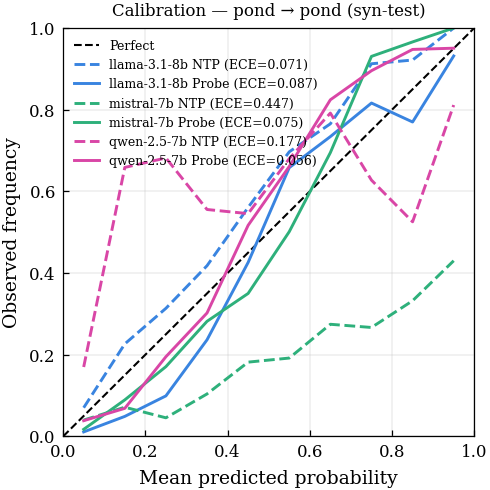


Summary table (pond → pond (syn-test), threshold=0.5):
 Judge model           Type  Recovery  Hallucination   Acc  Prec    F1  AUROC   ECE
llama-3.1-8b   NTP baseline     0.331          0.218 0.746 0.782 0.465  0.810 0.071
llama-3.1-8b Probe (EM-cal)     0.753          0.249 0.834 0.751 0.752  0.893 0.087
  mistral-7b   NTP baseline     0.965          0.593 0.520 0.407 0.573  0.712 0.447
  mistral-7b Probe (EM-cal)     0.684          0.255 0.817 0.745 0.713  0.881 0.075
 qwen-2.5-7b   NTP baseline     0.543          0.216 0.798 0.784 0.641  0.874 0.177
 qwen-2.5-7b Probe (EM-cal)     0.747          0.149 0.872 0.851 0.795  0.922 0.056


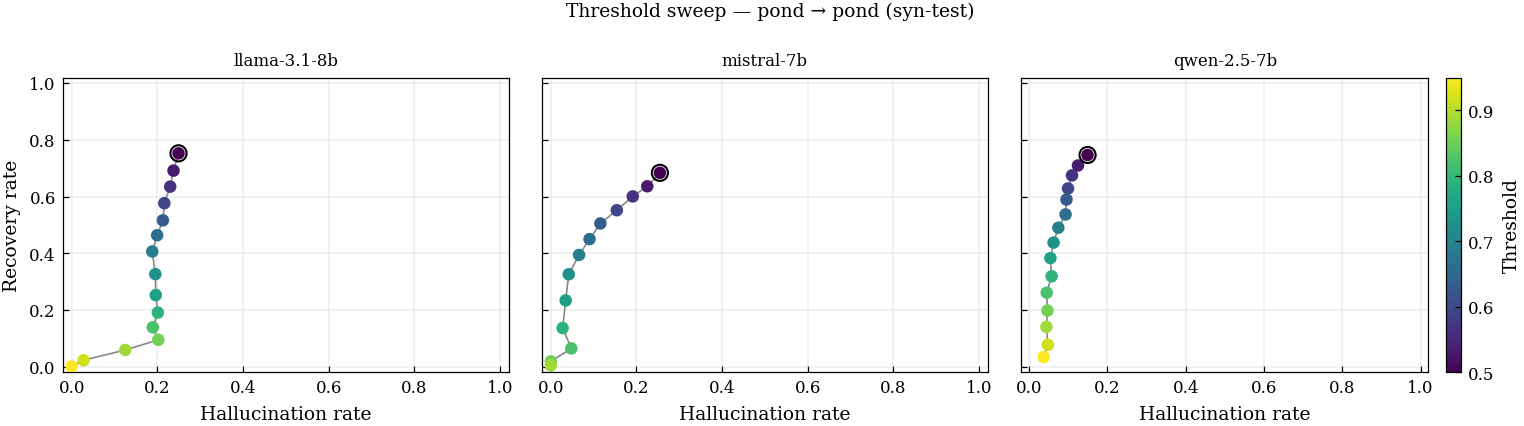

In [8]:
summary_syn_pond_pond = analyze_synthetic_combination('pond', 'pond')

### nfix_synthetic → nfix_synthetic


  Probe trained on: nfix    Tested on: nfix (synthetic test)
  llama-3.1-8b: 1347 records, pos=449 (33.3%)
  llama-3.1-8b: EM pi_te_hat=0.000 (pi_tr=0.333)
  mistral-7b: 1347 records, pos=449 (33.3%)
  mistral-7b: EM pi_te_hat=0.025 (pi_tr=0.333)
  qwen-2.5-7b: 1347 records, pos=449 (33.3%)
  qwen-2.5-7b: EM pi_te_hat=0.217 (pi_tr=0.333)


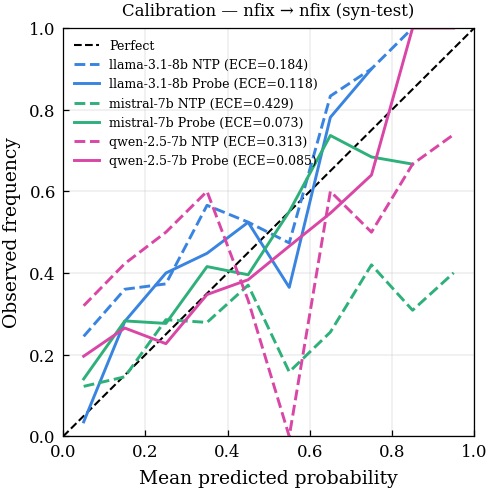


Summary table (nfix → nfix (syn-test), threshold=0.5):
 Judge model           Type  Recovery  Hallucination   Acc  Prec    F1  AUROC   ECE
llama-3.1-8b   NTP baseline     0.069          0.295 0.680 0.705 0.126  0.656 0.184
llama-3.1-8b Probe (EM-cal)     0.136          0.474 0.671 0.526 0.216  0.694 0.118
  mistral-7b   NTP baseline     0.869          0.625 0.474 0.375 0.524  0.614 0.429
  mistral-7b Probe (EM-cal)     0.265          0.377 0.702 0.623 0.372  0.679 0.073
 qwen-2.5-7b   NTP baseline     0.051          0.324 0.676 0.676 0.095  0.645 0.313
 qwen-2.5-7b Probe (EM-cal)     0.379          0.443 0.693 0.557 0.451  0.677 0.085


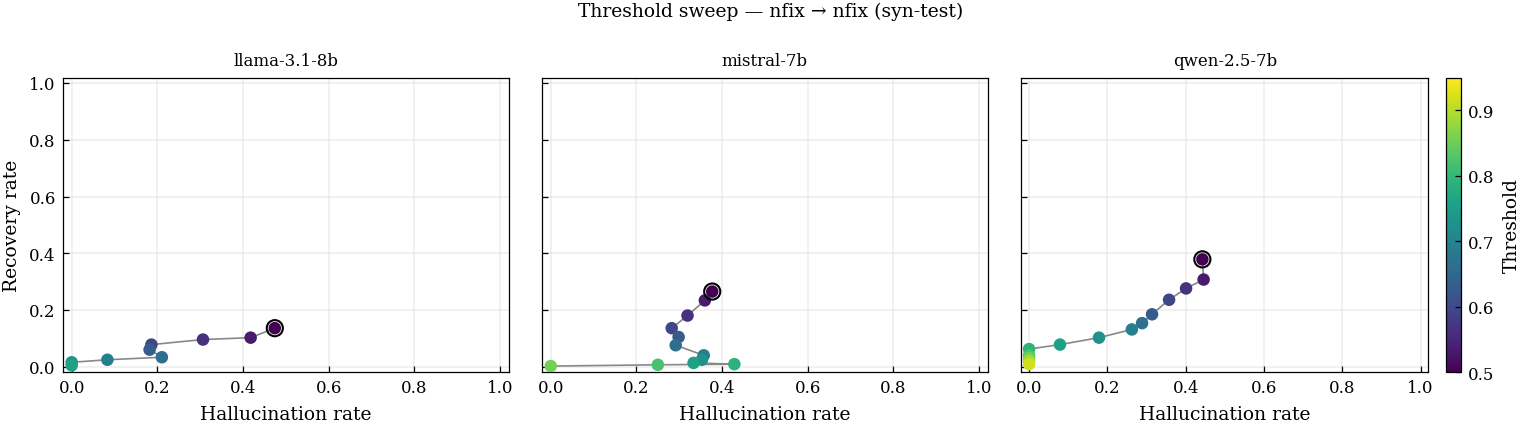

In [9]:
summary_syn_nfix_nfix = analyze_synthetic_combination('nfix', 'nfix')

### Cross-Domain Evaluation

### pond_synthetic → nfix_synthetic


  Probe trained on: pond    Tested on: nfix (synthetic test)
  llama-3.1-8b: 1347 records, pos=449 (33.3%)
  llama-3.1-8b: EM pi_te_hat=0.497 (pi_tr=0.333)
  mistral-7b: 1347 records, pos=449 (33.3%)
  mistral-7b: EM pi_te_hat=0.806 (pi_tr=0.333)
  qwen-2.5-7b: 1347 records, pos=449 (33.3%)
  qwen-2.5-7b: EM pi_te_hat=0.007 (pi_tr=0.333)


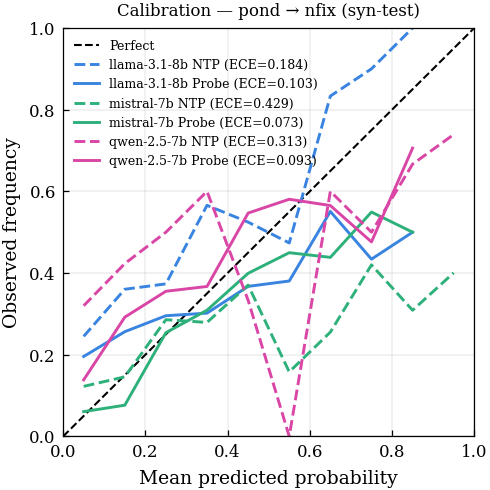


Summary table (pond → nfix (syn-test), threshold=0.5):
 Judge model           Type  Recovery  Hallucination   Acc  Prec    F1  AUROC   ECE
llama-3.1-8b   NTP baseline     0.069          0.295 0.680 0.705 0.126  0.656 0.184
llama-3.1-8b Probe (EM-cal)     0.379          0.549 0.639 0.451 0.412  0.617 0.103
  mistral-7b   NTP baseline     0.869          0.625 0.474 0.375 0.524  0.614 0.429
  mistral-7b Probe (EM-cal)     0.421          0.537 0.644 0.463 0.441  0.664 0.073
 qwen-2.5-7b   NTP baseline     0.051          0.324 0.676 0.676 0.095  0.645 0.313
 qwen-2.5-7b Probe (EM-cal)     0.227          0.424 0.687 0.576 0.326  0.694 0.093


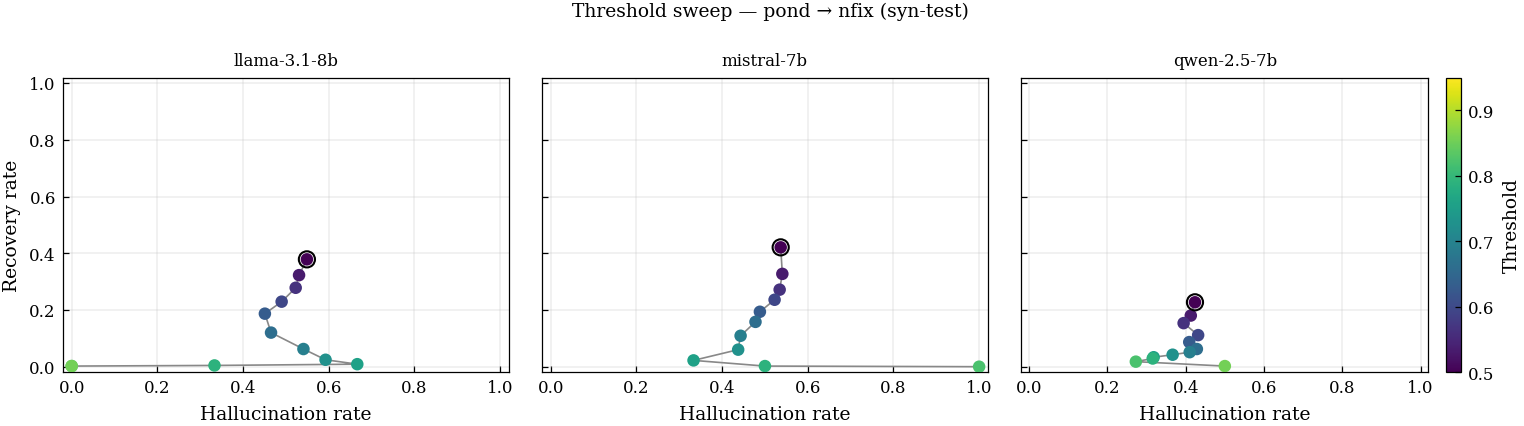

In [10]:
summary_syn_pond_nfix = analyze_synthetic_combination('pond', 'nfix')

### nfix_synthetic → pond_synthetic


  Probe trained on: nfix    Tested on: pond (synthetic test)
  llama-3.1-8b: 4620 records, pos=1540 (33.3%)
  llama-3.1-8b: EM pi_te_hat=0.000 (pi_tr=0.333)
  mistral-7b: 4620 records, pos=1540 (33.3%)
  mistral-7b: EM pi_te_hat=0.812 (pi_tr=0.333)
  qwen-2.5-7b: 4620 records, pos=1540 (33.3%)
  qwen-2.5-7b: EM pi_te_hat=0.100 (pi_tr=0.333)


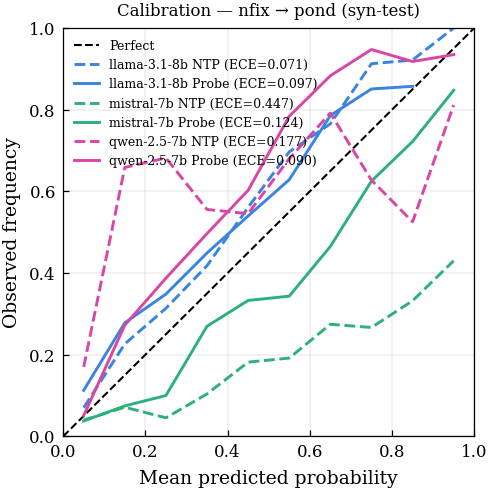


Summary table (nfix → pond (syn-test), threshold=0.5):
 Judge model           Type  Recovery  Hallucination   Acc  Prec    F1  AUROC   ECE
llama-3.1-8b   NTP baseline     0.331          0.218 0.746 0.782 0.465  0.810 0.071
llama-3.1-8b Probe (EM-cal)     0.241          0.289 0.714 0.711 0.360  0.744 0.097
  mistral-7b   NTP baseline     0.965          0.593 0.520 0.407 0.573  0.712 0.447
  mistral-7b Probe (EM-cal)     0.686          0.482 0.682 0.518 0.590  0.768 0.124
 qwen-2.5-7b   NTP baseline     0.543          0.216 0.798 0.784 0.641  0.874 0.177
 qwen-2.5-7b Probe (EM-cal)     0.492          0.119 0.808 0.881 0.631  0.883 0.090


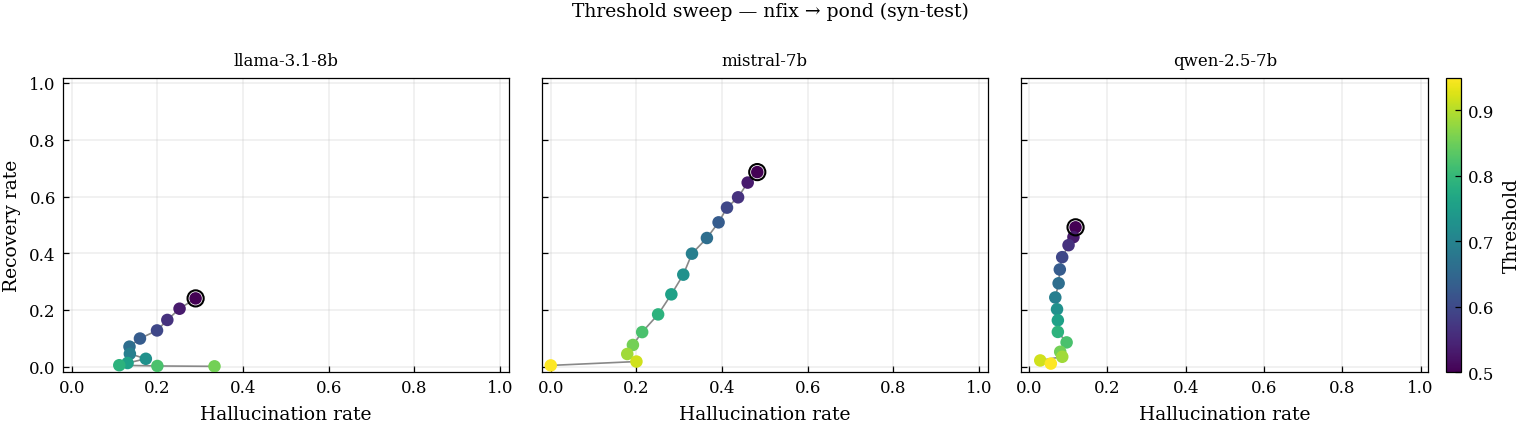

In [11]:
summary_syn_nfix_pond = analyze_synthetic_combination('nfix', 'pond')

---
# Real Data Evaluation

## Judge Baselines

Since our labels for real data are partially constructed by LLM judges, we need to evaluate
how accurate this process. 

Therefore, we evaluate non-probe judge models (frontier or local vLLM) on the full synthetic
dataset using their binary `judgement` outputs from `responses.json`.  These
runs must have been produced with `--synthetic` on one of the non-interp judge
scripts (`run_judge_frontier_v2.py`, `run_judge_local.py`, etc.).

**Metrics:** Accuracy · Precision · Recall · F1 (all for the `valid` class)  
AUROC is omitted — these backends return binary verdicts, not soft probabilities.

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
# Each entry: (short model name used as the judge dir, judge_date or None for latest)
ALT_JUDGE_MODELS = [
    ('gpt-4o-mini',               None),
    ('claude-haiku-4-5-20251001', None),
]

# ── Evaluation ────────────────────────────────────────────────────────────────
gt_by_id = dict(zip(syn_df['measurement_id'], syn_labels))

rows = []
for model_name, judge_date in ALT_JUDGE_MODELS:
    try:
        responses = load_synthetic_responses(DATASET, model_name, judge_date)
    except FileNotFoundError as e:
        print(f'  [{model_name}] not found — skipping\n    {e}')
        continue

    y_true, y_pred, n_null = [], [], 0
    for r in responses:
        j = r.get('judgement')
        if j is None:
            n_null += 1
            continue
        mid = r['measurement_id']
        if mid not in gt_by_id:
            continue
        y_true.append(gt_by_id[mid])
        y_pred.append(bool(j))

    y_true = np.array(y_true, dtype=bool)
    y_pred = np.array(y_pred, dtype=bool)
    n   = len(y_true)
    acc = float((y_pred == y_true).mean()) if n > 0 else float('nan')
    tp  = int(( y_pred &  y_true).sum())
    fp  = int(( y_pred & ~y_true).sum())
    fn  = int((~y_pred &  y_true).sum())
    p   = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    r   = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1  = 2 * p * r / (p + r) if (p + r) > 0 else float('nan')
    rows.append(dict(model=model_name, n=n, n_null=n_null, acc=acc, prec=p, rec=r, f1=f1))

if rows:
    alt_df = pd.DataFrame(rows).set_index('model')
    display(alt_df.style.format({'acc': '{:.3f}', 'prec': '{:.3f}', 'rec': '{:.3f}', 'f1': '{:.3f}'}))

## Matching Configuration

In [8]:
_SUPER_MAP  = str.maketrans("⁰¹²³⁴⁵⁶⁷⁸⁹⁻⁺", "0123456789-+")
_SUB_MAP    = str.maketrans("₀₁₂₃₄₅₆₇₈₉₋₊", "0123456789-+")
_SCRIPT_MAP = {**_SUPER_MAP, **_SUB_MAP}

# ^{-2} or ^-1 style LaTeX exponents
_LATEX_RE = re.compile(r"[\^_]\{([^}]*)\}|[\^_]([+-]?\d+)")

# "{prefix}[ -]{CHEM}" → "{prefix}-{CHEM}"  where CHEM starts with an uppercase letter
# Handles both old dash notation (nmol-N) and new space notation (nmol N),
# and any chemical: N, N2, C2H4, etc.
_COMPOUND_RE = re.compile(r"(\w+)[\s\-]([A-Z][a-zA-Z0-9]*)")


def nfix_clean_unit(s: str) -> str:
    """Normalise an nfix unit string to the ground-truth format.

    Target: lowercase, hyphen-compound (nmol-n), ASCII exponents (-1/-2/-3),
    u for micro, y for year.

    Handles: new superscript notation (nmol N g⁻¹ h⁻¹), old dash notation
    (nmol-N g-1 h-1), LaTeX (^{-2}), µ symbol, yr vs y, day/hr variants.
    """
    if not isinstance(s, str):
        return s
    # 1. Unicode super/subscripts → ASCII
    s = s.translate(_SCRIPT_MAP)
    # 2. LaTeX-style exponents → ASCII  (^{-2} → -2, ^-1 → -1)
    s = _LATEX_RE.sub(lambda m: m.group(1) if m.group(1) is not None else m.group(2), s)
    # 3. Micro symbol → u
    s = s.replace('µ', 'u').replace('μ', 'u')
    # 4. Compound separator: normalise to hyphen
    #    "nmol N"  → "nmol-N",  "nmol-N"  → "nmol-N" (no-op),
    #    "nmol N2" → "nmol-N2", "ug N"    → "ug-N"
    s = _COMPOUND_RE.sub(r"\1-\2", s)
    # 5. yr → y  (before lowercasing; \b works because - is a non-word char)
    s = re.sub(r'\byr\b', 'y', s)
    # 6. Lowercase everything (L→l, N→n, C→c, etc.)
    s = s.lower()
    # 7. Remaining time-unit variants
    s = re.sub(r'\bday\b', 'd', s)
    s = re.sub(r'\bhr\b',  'h', s)
    return s

def get_matching_config(dataset):
    """Return (strict_matching, fuzzy_matching) dicts for a dataset."""
    if dataset == 'pond':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                  'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
    elif dataset == 'nfix':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                  'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'site_type': 'site_type'}
    else:
        raise ValueError(f'Unknown dataset: {dataset}')
    return strict, fuzzy

## Load and Cache Test Data

For each test dataset: load extraction results, combined judgements, ground truth,
compute union labels (matching OR frontier judge), and run `cached_match`.

In [ ]:
test_data = {}  # test_data[dataset] = dict with pre-loaded data

for ds in DATASETS:
    print(f'Loading test data for {ds}...')
    if 'synthetic' in ds:
        
    
    config = load_dataset_config(ds)
    records = load_extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds])
    ext_df = pd.DataFrame(records)
    ext_df = apply_unit_conversion(ext_df, config.unit_conversion_table)

    if ds == 'nfix':
        ext_df['attribute'] = ext_df['attribute'].map({
            'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate',
            'nfix_rate_mass': 'nfix_rate', 'nfix_rate': 'nfix_rate',
        })
        ext_df['units'] = ext_df['units'].apply(nfix_clean_unit)

    real_df = pd.DataFrame(load_combined_judgements(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]))
    gt_df = load_ground_truth(config)

    strict, fuzzy = get_matching_config(ds)
    cache_path = paths.extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]) / 'match_cache.pkl'
    matching, edges, edge_weights = cached_match(
        gt_df, ext_df,
        strict_matching=strict,
        fuzzy_matching=fuzzy,
        fuzzy_threshold=0.0,
        cache_path=cache_path,
    )

    # Union labels: positive if GT-matched OR frontier judge says valid
    ex_edge_exists = np.zeros(len(ext_df), dtype=bool)
    for (gt_idx, ex_idx), w in zip(edges, edge_weights):
        if w > EDGE_THRESHOLD:
            ex_edge_exists[int(ex_idx)] = True
    jlabels     = real_df['judgement_combined'].to_numpy(dtype=bool)
    real_labels = jlabels | ex_edge_exists

    test_data[ds] = {
        'extraction_df':  ext_df,
        'real_df':        real_df,
        'ground_truth_df': gt_df,
        'real_labels':    real_labels,
        'ex_edge_exists': ex_edge_exists,
        'edges':          edges,
        'edge_weights':   edge_weights,
    }

    pos = real_labels.sum()
    print(f'  {ds}: {len(ext_df)} extractions, {len(gt_df)} GT rows, '
          f'pos={pos} ({pos/len(real_labels):.1%})')
    print()

In [15]:
def analyze_combination(train_dataset, test_dataset):
    """Produce all outputs for one (train_dataset → test_dataset) combination."""
    label = f'{train_dataset} \u2192 {test_dataset}'
    print(f'\n{"="*72}')
    print(f'  Probe trained on: {train_dataset}    Tested on: {test_dataset}')
    print(f'{"="*72}')

    td = test_data[test_dataset]
    real_df         = td['real_df']
    ground_truth_df = td['ground_truth_df']
    real_labels_all = td['real_labels']
    edges           = td['edges']
    edge_weights    = td['edge_weights']
    n_gt            = len(ground_truth_df)

    # Union of syn_document_ids across all judge models for train_dataset
    # Note: this should be the same for all judge models, we use the same synthetic 
    # training set everywhere.
    syn_doc_ids = set()
    for jm in JUDGE_MODELS:
        syn_doc_ids.update(probe_cache[train_dataset][jm]['syn_document_ids'])

    # Filter: exclude test records from papers seen during synthetic training
    real_test_mask = ~real_df['document_id'].isin(syn_doc_ids)
    real_test_idx = np.where(real_test_mask.to_numpy())[0]

    # NOTE: you might need to think about whether measurement id is necessary (don't have it for synthetic)
    real_test_mids = real_df['measurement_id'].iloc[real_test_idx].tolist()

    # NOTE: the synthetic set should not be sub-indexed (it's already a test set)
    real_test_labels = real_labels_all[real_test_idx]
    
    n_test = len(real_test_idx)
    n_pos  = real_test_labels.sum()

    print(f'  Test records   : {n_test}  pos={n_pos} ({n_pos/n_test:.1%})')
    print(f'  Excluded       : {(~real_test_mask).sum()} records '
          f'({real_df.loc[~real_test_mask, "document_id"].nunique()} papers from syn set)')

    # Precompute edges restricted to the test set (for threshold sweep)
    ex_to_test_pos = {int(real_test_idx[i]): i for i in range(n_test)}
    test_edges = [
        (int(gt_idx), ex_to_test_pos[int(ex_idx)])
        for (gt_idx, ex_idx), w in zip(edges, edge_weights)
        if int(ex_idx) in ex_to_test_pos and w > EDGE_THRESHOLD
    ]

    # ── Compute probabilities for each judge model ──────────────────────────
    ntp_probs_by_judge   = {}  # NTP baseline
    probe_probs_by_judge = {}  # EM-rescaled probe

    for jm in JUDGE_MODELS:
        pd_data = probe_cache[train_dataset][jm]
        top_k   = pd_data['top_k_heads']

        jdate = JUDGE_DATES_REAL.get(test_dataset, {}).get(jm, None)
        real_activations = load_activations(
            test_dataset, EXTRACTION_MODEL, EXTRACTION_DATES[test_dataset], jm, jdate
        )

        _all_real = {
            str(mid): np.array(real_activations[str(mid)], dtype=np.float32)
            for mid in real_test_mids
        }
        X_real = np.concatenate(
            [
                np.stack([_all_real[str(mid)][l, h, :] for mid in real_test_mids], axis=0)
                for l, h in top_k
            ],
            axis=1,
        )

        raw_probs = pd_data['probe'].predict_proba(X_real)[:, 1]
        cal_probs, pi_te_hat = rescale_probabilities_em(
            raw_probs, pi_tr=pd_data['train_prevalence']
        )
        print(f'  {jm}: EM pi_te_hat={pi_te_hat:.3f} (pi_tr={pd_data["train_prevalence"]:.3f})')

        ntp_probs_by_judge[jm]   = real_df[f'judgement_p_true_{jm}'].iloc[real_test_idx].to_numpy()
        probe_probs_by_judge[jm] = cal_probs

    # ── Figure 1: Calibration curves ────────────────────────────────────────
    fig_cal, ax_cal = plt.subplots(figsize=(3.5, 3.5))
    ax_cal.plot([0, 1], [0, 1], 'k--', lw=1.0, label='Perfect')

    for jm in JUDGE_MODELS:
        color = JUDGE_COLORS[jm]
        for probs, linestyle, tag in [
            (ntp_probs_by_judge[jm],   '--', 'NTP'),
            (probe_probs_by_judge[jm], '-',  'Probe'),
        ]:
            d     = reliability_diagram_data(probs, real_test_labels)
            valid = ~np.isnan(d['bin_accuracy'])
            ax_cal.plot(
                d['bin_centers'][valid], d['bin_accuracy'][valid],
                linestyle, color=color, lw=1.4, ms=3.5,
                label=f'{jm} {tag} (ECE={d["ece"]:.3f})',
            )

    ax_cal.set_xlim(0, 1); ax_cal.set_ylim(0, 1)
    ax_cal.set_xlabel('Mean predicted probability')
    ax_cal.set_ylabel('Observed frequency')
    ax_cal.legend(fontsize=6, loc='upper left')
    ax_cal.grid(alpha=0.2)
    fig_cal.tight_layout()
    #fig_cal.savefig(
    #    FIGURES_DIR + f'synprobe_test_cal_{train_dataset}_to_{test_dataset}.pdf',
    #    bbox_inches='tight',
    #)
    plt.show()

    # ── Table: metrics at threshold = 0.5 ───────────────────────────────────
    rows = []
    for jm in JUDGE_MODELS:
        for probs, kind in [
            (ntp_probs_by_judge[jm],   'NTP baseline'),
            (probe_probs_by_judge[jm], 'Probe (EM-cal)'),
        ]:
            # 1. Keep your existing custom rates
            rec, hall = compute_rates(
                probs, 0.5, real_test_labels, test_edges, n_gt
            )
            
            # 2. Call the helper function for standard metrics
            metrics = _probe_metrics(probs, real_test_labels, threshold=0.5)
            
            # 3. Append everything to the row
            rows.append({
                'Judge model': jm,
                'Type':        kind,
                'Recovery':    rec,
                'Hallucination': hall,
                'Acc':         metrics['acc'],
                'Prec':        metrics['prec'],
                'F1':          metrics['f1'],
                'AUROC':       metrics['auroc'],
                'ECE':         metrics['ece'],
            })

    summary_df = pd.DataFrame(rows)
    print(f'\nSummary table ({label}, threshold=0.5):')
    print(summary_df.to_string(index=False, float_format='{:.3f}'.format))

    # ── Figure 2: Threshold sweep ────────────────────────────────────────────
    n_judges = len(JUDGE_MODELS)
    fig_sweep, axes_sweep = plt.subplots(1, n_judges, figsize=(3.5 * n_judges, 3.0),
                                          sharey=True)
    if n_judges == 1:
        axes_sweep = [axes_sweep]

    cmap  = cm.viridis
    norm  = mcolors.Normalize(vmin=THRESHOLD_SWEEP.min(), vmax=THRESHOLD_SWEEP.max())
    sm    = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for ax, jm in zip(axes_sweep, JUDGE_MODELS):
        probs = probe_probs_by_judge[jm]
        sweep_rec  = []
        sweep_hall = []
        for t in THRESHOLD_SWEEP:
            r, h = compute_rates(probs, t, real_test_labels, test_edges, n_gt)
            sweep_rec.append(r)
            sweep_hall.append(h)

        sweep_rec  = np.array(sweep_rec)
        sweep_hall = np.array(sweep_hall)
        valid      = ~(np.isnan(sweep_rec) | np.isnan(sweep_hall))

        # Scatter colored by threshold
        sc = ax.scatter(
            sweep_hall[valid], sweep_rec[valid],
            c=THRESHOLD_SWEEP[valid], cmap=cmap, norm=norm,
            s=25, zorder=3,
        )
        ax.plot(sweep_hall[valid], sweep_rec[valid],
                '-', color='#888888', lw=0.8, zorder=2)

        # Mark threshold = 0.5
        idx0 = np.argmin(np.abs(THRESHOLD_SWEEP - 0.5))
        if valid[idx0]:
            ax.scatter([sweep_hall[idx0]], [sweep_rec[idx0]],
                       s=60, c='none', edgecolors='k', linewidths=1.0, zorder=4)

        ax.set_xlabel('Hallucination rate')
        if ax is axes_sweep[0]:
            ax.set_ylabel('Recovery rate')
        ax.set_title(jm, fontsize=8)
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.2)

    fig_sweep.colorbar(sm, ax=axes_sweep[-1], label='Threshold', fraction=0.046, pad=0.04)
    fig_sweep.suptitle(f'Threshold sweep — {label}', fontsize=9)
    fig_sweep.tight_layout()
    #fig_sweep.savefig(
    #    FIGURES_DIR + f'synprobe_test_sweep_{train_dataset}_to_{test_dataset}.pdf',
    #    bbox_inches='tight',
    #)
    plt.show()

    return summary_df

## Real Test Data — Within-Domain Evaluation

Probes trained and tested on the same dataset (no domain shift).

### pond → pond

In [ ]:
summary_pond_pond = analyze_combination('pond', 'pond')

### nfix → nfix

In [ ]:
summary_nfix_nfix = analyze_combination('nfix', 'nfix')

---
## Real Test Data — Cross-Domain Evaluation

Probes trained on one dataset and tested on the other.

### pond → nfix

In [ ]:
summary_pond_nfix = analyze_combination('pond', 'nfix')

### nfix → pond

In [ ]:
summary_nfix_pond = analyze_combination('nfix', 'pond')